In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def load_data(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    dfs = []

    for file in all_files:
        df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
        ticker = file.split('_')[0].upper()
        df['Ticker'] = ticker
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)
    return data

folder_path = r"C:\Users\natha\PycharmProjects\ML_Project\.venv\Dataset_clean\Stocks clean"

data = load_data(folder_path)

In [4]:
print("\n=== BASIC INFO ===")
print(data.info())

print("\n=== MISSING VALUES ===")
print(data.isnull().sum())

print("\n=== DESCRIPTIVE STATS ===")
print(data.describe())


=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277571 entries, 0 to 277570
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    277571 non-null  datetime64[ns]
 1   Open    277571 non-null  float64       
 2   High    277571 non-null  float64       
 3   Low     277571 non-null  float64       
 4   Close   277571 non-null  float64       
 5   Volume  277571 non-null  float64       
 6   Ticker  277571 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 14.8+ MB
None

=== MISSING VALUES ===
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64

=== DESCRIPTIVE STATS ===
                                Date           Open           High  \
count                         277571  277571.000000  277571.000000   
mean   1998-08-06 21:59:11.415673984      33.922888      34.273104   
min              1962-01-02 00

In [5]:
data = data.sort_values(['Ticker', 'Date'])
data.set_index('Date', inplace=True)
data['Return'] = data.groupby('Ticker')['Close'].pct_change()
ticker = data['Ticker'].unique()[1]
df = data[data['Ticker'] == ticker]

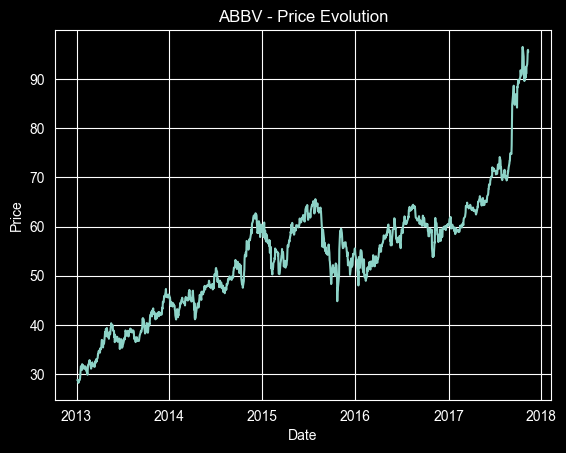

In [6]:
plt.figure()
plt.plot(df.index, df['Close'])
plt.title(f"{ticker} - Price Evolution")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

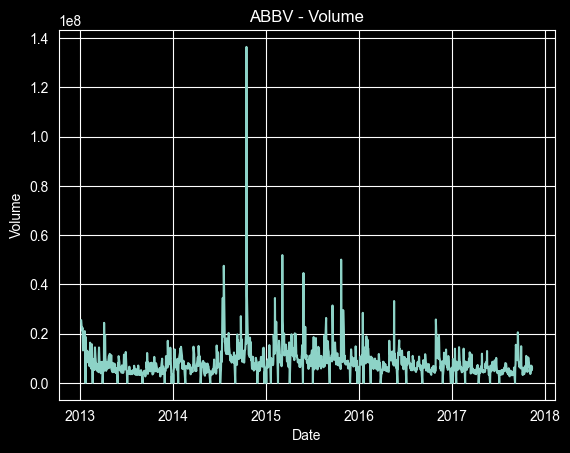

In [7]:
plt.figure()
plt.plot(df.index, df['Volume'])
plt.title(f"{ticker} - Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

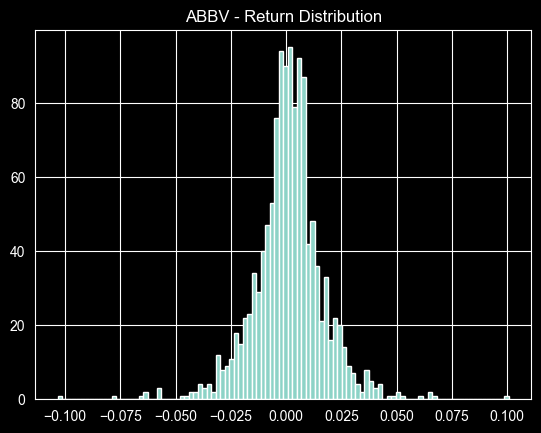

In [8]:
plt.figure()
plt.hist(df['Return'].dropna(), bins=100)
plt.title(f"{ticker} - Return Distribution")
plt.show()

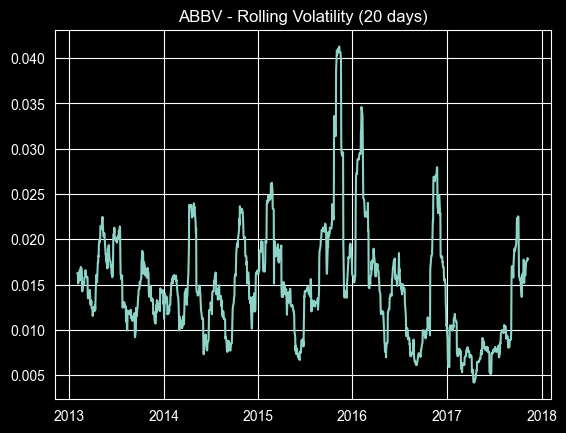

In [10]:
df = df.copy()
df['Volatility'] = df['Return'].rolling(20).std()

plt.figure()
plt.plot(df.index, df['Volatility'])
plt.title(f"{ticker} - Rolling Volatility (20 days)")
plt.show()

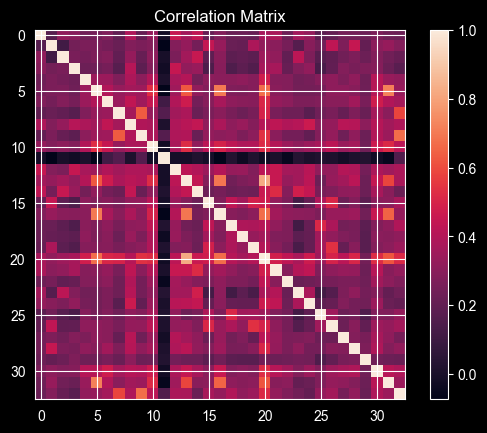

In [11]:
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')

correlation_matrix = pivot_close.pct_change().corr()

plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

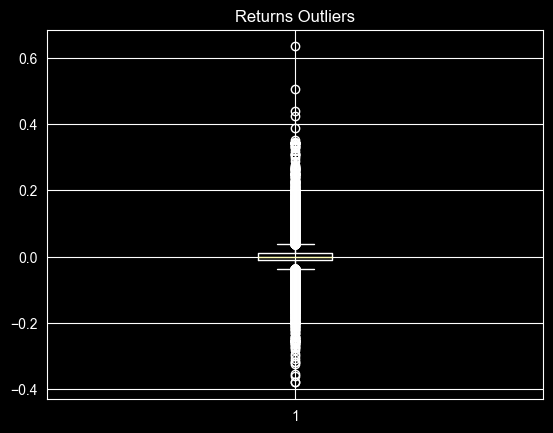

In [12]:
returns = data['Return'].dropna()

plt.figure()
plt.boxplot(returns)
plt.title("Returns Outliers")
plt.show()

In [13]:
sample_tickers = data['Ticker'].unique()[:5]

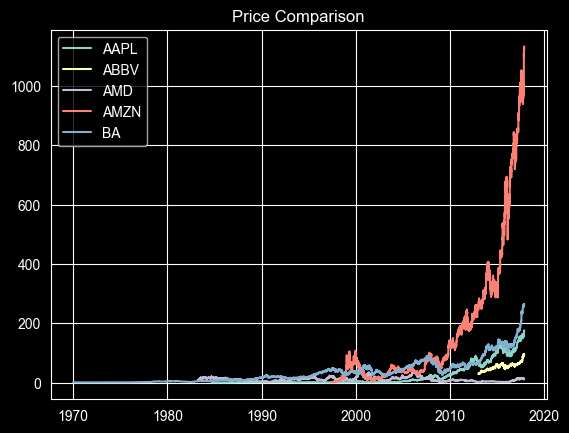

In [14]:
plt.figure()
for t in sample_tickers:
    temp = data[data['Ticker'] == t]
    plt.plot(temp.index, temp['Close'], label=t)

plt.legend()
plt.title("Price Comparison")
plt.show()

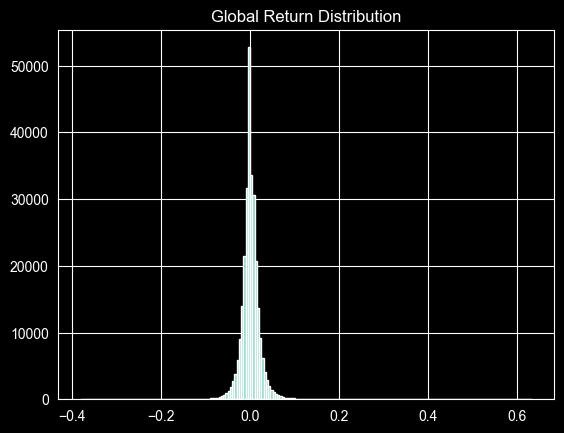

In [15]:
plt.figure()
plt.hist(data['Return'].dropna(), bins=200)
plt.title("Global Return Distribution")
plt.show()

In [16]:
print("Mean return:", data['Return'].mean())
print("Volatility:", data['Return'].std())
print("Max drawdown approx:", (data['Return'].min()))

Mean return: 0.0007106408897783843
Volatility: 0.021948542483275917
Max drawdown approx: -0.3793103448275862
           Ticker    Return
Date                       
1972-01-27   INTC  0.506321
2008-10-13     MS  0.633222
2000-03-07   NVDA  0.425018
1992-12-23   ORCL  0.437735
